# Análise — Despesas das Capitais (Siconfi/FINBRA, 2020–2025)

Comparação das despesas por **função** entre as 26 capitais brasileiras, com foco
na diferença entre o que foi **empenhado** (reservado) e o que foi **pago**
(saiu do caixa) — a chamada **Taxa de Execução**.

Fonte: `data/processed/finbra_consolidado.parquet`, gerado pelo pipeline (`src/main.py`).

In [1]:
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

def achar_parquet() -> Path:
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        alvo = pasta / "data" / "processed" / "finbra_consolidado.parquet"
        if alvo.exists():
            return alvo
    raise FileNotFoundError("Parquet não encontrado — rode src/main.py primeiro.")

df = pd.read_parquet(achar_parquet())
print("linhas, colunas:", df.shape)
df.head()

linhas, colunas: (50334, 10)


,instituicao,cod_ibge,uf,populacao,estagio,conta,id_conta,valor,ano,tipo_conta
0,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,Despesas Exceto Intraorçamentárias,siconfi-cor_TotalDespesas,8.748853e+08,2020,agregado_total
1,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,01 - Legislativa,siconfi-cor_TotalDespesas,2.901406e+07,2020,funcao
2,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,01.031 - Ação Legislativa,siconfi-cor_TotalDespesas,2.901406e+07,2020,subfuncao
3,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,03 - Essencial à Justiça,siconfi-cor_TotalDespesas,1.882290e+07,2020,funcao
4,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,03.092 - Representação Judicial e Extrajudicial,siconfi-cor_TotalDespesas,1.882290e+07,2020,subfuncao


## 1. Taxa de Execução por função

Para comparar **empenhado × pago**, precisamos dos dois na mesma linha. Então:

1. Filtrei só as linhas de **função** (`tipo_conta == "funcao"`) — assim os
   agregados (totais e `FUxx`) ficam de fora e não contamos valor em dobro.
2. **Pivotei** os estágios da despesa (empenhado, pago...) de linhas para colunas.
3. Calculei a **Taxa de Execução** = `pago / empenhado × 100`.

In [4]:
RENOMEAR_ESTAGIOS = {
    "Despesas Empenhadas": "empenhado",
    "Despesas Liquidadas": "liquidado",
    "Despesas Pagas": "pago",
    "Inscrição de Restos a Pagar Processados": "restos_processados",
    "Inscrição de Restos a Pagar Não Processados": "restos_nao_processados",
}

funcoes = df[df["tipo_conta"] == "funcao"]

funcoes_wide = funcoes.pivot_table(
    index=["ano", "cod_ibge", "instituicao", "uf", "populacao", "conta"],
    columns="estagio",
    values="valor",
    aggfunc="sum",
).reset_index()

funcoes_wide = funcoes_wide.rename(columns=RENOMEAR_ESTAGIOS)
funcoes_wide = funcoes_wide.rename_axis(columns=None)

funcoes_wide["taxa_execucao"] = (
    (funcoes_wide["pago"] / funcoes_wide["empenhado"] * 100)
    .where(funcoes_wide["empenhado"] > 0)
    .round(1)
)

print("shape:", funcoes_wide.shape)

maceio_saude = funcoes_wide[
    (funcoes_wide["conta"] == "10 - Saúde")
    & (funcoes_wide["instituicao"].str.contains("Maceió"))
]
maceio_saude[["ano", "empenhado", "pago", "taxa_execucao"]]

shape: (2806, 12)


,ano,empenhado,pago,taxa_execucao
257,2020,7.920658e+08,7.814727e+08,98.7
767,2021,7.741342e+08,7.559851e+08,97.7
1276,2022,8.729671e+08,8.587153e+08,98.4
1796,2023,1.302782e+09,1.274498e+09,97.8
2318,2024,1.297135e+09,1.262956e+09,97.4


## 2. Maceió: Saúde vs Educação — o contraste

Maceió executa a Saúde muito bem (~97%). Será que o bom desempenho se repete
em Educação? Para uma comparação justa entre capitais de tamanhos diferentes,
olhamos o gasto **por habitante** (`pago / população`), não o valor absoluto.

In [5]:
funcoes_wide["pago_per_capita"] = (funcoes_wide["pago"] / funcoes_wide["populacao"]).round(2)

def posicao_maceio(ano: int, conta: str) -> pd.Series:
    sub = funcoes_wide[(funcoes_wide["ano"] == ano) & (funcoes_wide["conta"] == conta)].copy()

    sub["rank"] = sub["pago_per_capita"].rank(ascending=False, method="min").astype(int)

    maceio = sub[sub["instituicao"].str.contains("Maceió")].iloc[0]

    return pd.Series({
        "per_capita_pago": maceio["pago_per_capita"],
        "taxa_execucao": maceio["taxa_execucao"],
        "rank": f"{maceio['rank']}º de {len(sub)}",
    })

comparacao = pd.DataFrame({
    "Saúde (2024)": posicao_maceio(2024, "10 - Saúde"),
    "Educação (2024)": posicao_maceio(2024, "12 - Educação"),
})

comparacao

,Saúde (2024),Educação (2024)
per_capita_pago,1314.67,715.71
taxa_execucao,97.4,85.5
rank,13º de 26,25º de 26


### Ranking das capitais por gasto per capita

Gráfico **interativo**: compara as 26 capitais pelo gasto **por habitante**
(`pago ÷ população`) em qualquer função e ano. **Maceió** aparece sempre em
**vermelho** para facilitar localizá-la; as demais capitais em cinza.

Troque a função (e o ano) na célula abaixo para explorar diferentes áreas.
Um exemplo revelador é o contraste de Maceió em 2024: **mediana na Saúde**
(`10 - Saúde`), mas **penúltima na Educação** (`12 - Educação`).

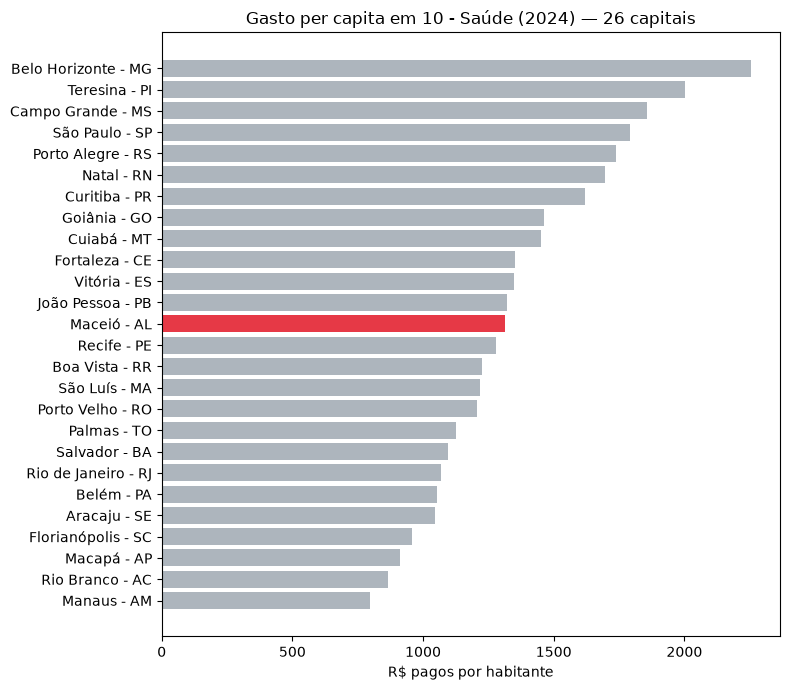

In [10]:
import matplotlib.pyplot as plt

COR_MACEIO = "#E63946" 
COR_OUTRAS_CAPITAIS = "#adb5bd"

# Troque a função abaixo para explorar outras áreas (copie um dos exemplos):
#   "10 - Saúde"        "12 - Educação"       "15 - Urbanismo"
#   "16 - Habitação"    "08 - Assistência Social"   "17 - Saneamento"
#   "27 - Desporto e Lazer"   "18 - Gestão Ambiental"   "13 - Cultura"

def grafico_ranking_per_capita(ano: int, conta: str):
    sub = funcoes_wide[(funcoes_wide["ano"] == ano) & (funcoes_wide["conta"] == conta)].copy()

    sub["nome"] = sub["instituicao"].str.replace(r"Prefeitura Municipal d[eo] ", "", regex=True)

    sub = sub.sort_values("pago_per_capita")

    cores = [COR_MACEIO if "Maceió" in n else COR_OUTRAS_CAPITAIS for n in sub["nome"]]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(sub["nome"], sub["pago_per_capita"], color=cores)
    ax.set_title(f"Gasto per capita em {conta} ({ano}) — {len(sub)} capitais")
    ax.set_xlabel("R$ pagos por habitante")
    plt.tight_layout()
    plt.show()

grafico_ranking_per_capita(2024, "10 - Saúde")

## 3. Ranking de execução — quem paga mais do que empenha

A **Taxa de Execução geral** de uma capital (pago ÷ empenhado, somando todas as
funções) mede quanto do que ela reservou no orçamento realmente saiu do caixa
no ano. Taxa baixa = muito gasto empurrado para o ano seguinte (restos a pagar).

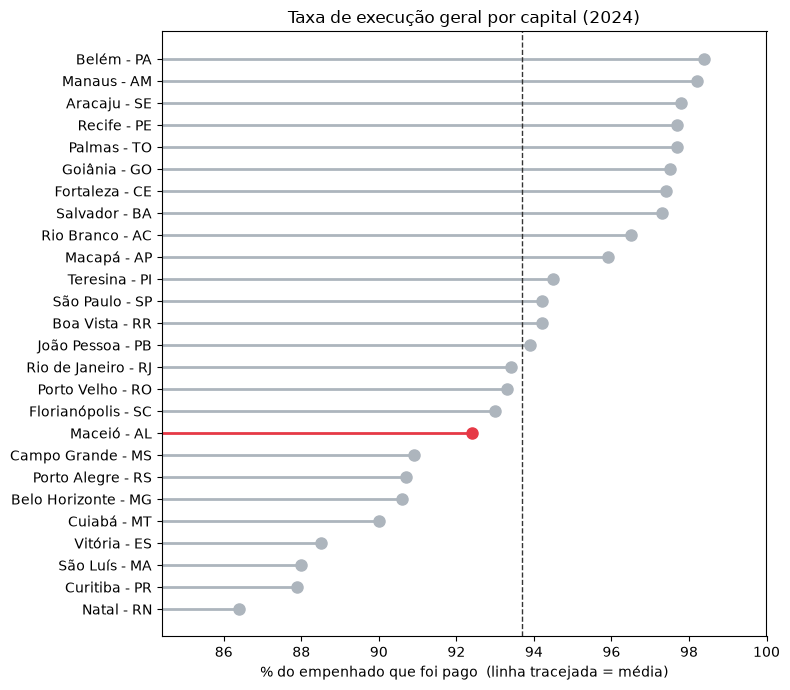

In [11]:
def ranking_execucao(ano: int) -> pd.DataFrame:
    g = (
        funcoes_wide[funcoes_wide["ano"] == ano]
        .groupby("instituicao", as_index=False)
        .agg(empenhado=("empenhado", "sum"), pago=("pago", "sum"))
    )

    g["taxa_execucao"] = (g["pago"] / g["empenhado"] * 100).round(1)

    g["nome"] = g["instituicao"].str.replace(r"Prefeitura Municipal d[eo] ", "", regex=True)

    return g.sort_values("taxa_execucao", ascending=False).reset_index(drop=True)


def grafico_execucao(ano: int):
    g = ranking_execucao(ano).sort_values("taxa_execucao")

    cores = [COR_MACEIO if "Maceió" in n else COR_OUTRAS_CAPITAIS for n in g["nome"]]

    base = g["taxa_execucao"].min() - 2   # eixo começa perto do menor valor

    fig, ax = plt.subplots(figsize=(8, 7))

    ax.hlines(g["nome"], base, g["taxa_execucao"], color=cores, linewidth=2)

    for x, y, cor in zip(g["taxa_execucao"], g["nome"], cores):
        ax.plot(x, y, "o", color=cor, markersize=8)
        
    ax.axvline(g["taxa_execucao"].mean(), color="#333", linestyle="--", linewidth=1)
    ax.set_xlim(base, 100)
    ax.set_title(f"Taxa de execução geral por capital ({ano})")
    ax.set_xlabel("% do empenhado que foi pago  (linha tracejada = média)")
    plt.tight_layout()
    plt.show()

grafico_execucao(2024)

## 4. Evolução no tempo — Maceió vs média das capitais

Olhar a **taxa de execução ao longo dos anos** revela padrões que a foto de um
ano só esconde. Enquanto a média das 26 capitais é estável, a execução de Maceió
em algumas funções é uma montanha-russa. O caso extremo é a **Habitação em 2021**:
Maceió empenhou ~R$ 929 mil e pagou **R$ 305** — deixando quase tudo em restos a pagar.

*(2025 fica de fora das séries temporais por ter apenas 11 das 26 capitais.)*

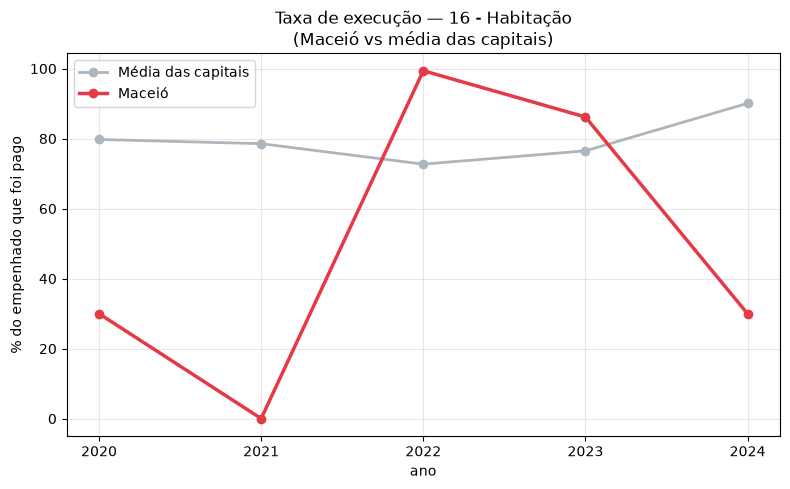

In [12]:
def grafico_evolucao(conta: str):
    sub = funcoes_wide[(funcoes_wide["conta"] == conta) & (funcoes_wide["ano"] <= 2024)]

    def taxa_por_ano(d):
        agg = d.groupby("ano")[["pago", "empenhado"]].sum()

        return agg["pago"] / agg["empenhado"] * 100

    media = taxa_por_ano(sub)
    maceio = taxa_por_ano(sub[sub["instituicao"].str.contains("Maceió")])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(media.index, media.values, "o-", color=COR_OUTRAS_CAPITAIS, linewidth=2, label="Média das capitais")
    ax.plot(maceio.index, maceio.values, "o-", color=COR_MACEIO, linewidth=2.5, label="Maceió")
    ax.set_title(f"Taxa de execução — {conta}\n(Maceió vs média das capitais)")
    ax.set_ylabel("% do empenhado que foi pago")
    ax.set_xlabel("ano")
    ax.set_xticks([2020, 2021, 2022, 2023, 2024])
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

grafico_evolucao("16 - Habitação")

## 5. Concentração por subfunção — para onde vai o dinheiro de uma função

Cada função se divide em **subfunções**. Ver a distribuição interna mostra as
*prioridades dentro da área*. Na Saúde de Maceió, o gasto é fortemente concentrado:
a maior parte vai para atendimento hospitalar, e a Atenção Básica (porta de entrada
do SUS) fica em segundo.

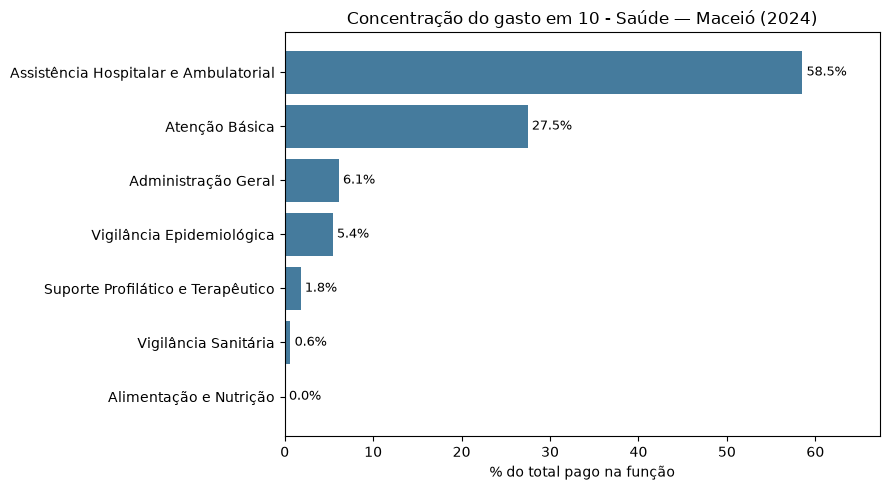

In [13]:
#  Troque a função para ver a concentração de subfunções de outra área:
#   "10 - Saúde"         "12 - Educação"        "08 - Assistência Social"
#   "15 - Urbanismo"     "04 - Administração"   "18 - Gestão Ambiental"

def grafico_subfuncoes(conta_funcao: str, ano: int = 2024):
    codigo = conta_funcao.split(" - ")[0]

    pago = df[
        (df["estagio"] == "Despesas Pagas")
        & (df["ano"] == ano)
        & (df["instituicao"].str.contains("Maceió"))
    ]

    subs = pago[
        (pago["tipo_conta"] == "subfuncao")
        & (pago["conta"].str.startswith(codigo + "."))
    ].copy()

    subs["pct"] = subs["valor"] / subs["valor"].sum() * 100
    subs["label"] = subs["conta"].str.replace(r"^\d+\.\d+ - ", "", regex=True)
    subs = subs.sort_values("valor")

    fig, ax = plt.subplots(figsize=(9, 5))
    barras = ax.barh(subs["label"], subs["pct"], color="#457B9D")
    ax.bar_label(barras, labels=[f"{p:.1f}%" for p in subs["pct"]], padding=3, fontsize=9)
    ax.set_title(f"Concentração do gasto em {conta_funcao} — Maceió ({ano})")
    ax.set_xlabel("% do total pago na função")
    ax.set_xlim(0, subs["pct"].max() * 1.15)
    plt.tight_layout()
    plt.show()

grafico_subfuncoes("10 - Saúde")

## 6. Comparação por região

Agrupando as 26 capitais nas **5 regiões** do IBGE, surge um padrão contra-intuitivo:
as regiões **mais pobres (Norte/Nordeste) executam uma proporção maior** do que
empenham, mas **gastam bem menos por habitante**. As mais ricas (Sudeste) gastam
quase o dobro per capita, porém deixam mais em restos a pagar.

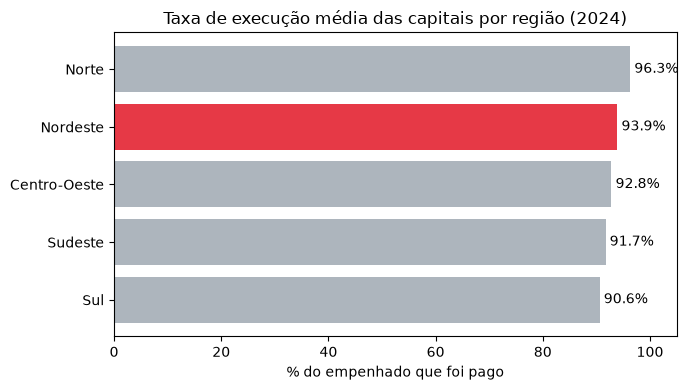

In [15]:
REGIAO = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste", "DF": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}
funcoes_wide["regiao"] = funcoes_wide["uf"].map(REGIAO)

def grafico_regioes(ano: int = 2024):
    sub = funcoes_wide[funcoes_wide["ano"] == ano]

    cap = sub.groupby(["instituicao", "regiao"], as_index=False).agg(
        empenhado=("empenhado", "sum"), pago=("pago", "sum")
    )

    cap["taxa_execucao"] = cap["pago"] / cap["empenhado"] * 100
    media = cap.groupby("regiao")["taxa_execucao"].mean().round(1).sort_values()

    cores = [COR_MACEIO if r == "Nordeste" else COR_OUTRAS_CAPITAIS for r in media.index]
    
    fig, ax = plt.subplots(figsize=(7, 4))
    barras = ax.barh(media.index, media.values, color=cores)
    ax.bar_label(barras, fmt="%.1f%%", padding=3)
    ax.set_xlim(0, 105)
    ax.set_title(f"Taxa de execução média das capitais por região ({ano})")
    ax.set_xlabel("% do empenhado que foi pago")
    plt.tight_layout()
    plt.show()

grafico_regioes(2024)